# Soccermatics — Complete Learning Guide

**Based on:** [Soccermatics by David Sumpter](https://soccermatics.readthedocs.io) • Friends of Tracking YouTube channel  
**Data sources used:** Wyscout (EPL 2017-18, local files) • StatsBomb Open Data (via mplsoccer) • football-data.co.uk  
**License:** CC-BY-NC-SA

---

## What you will learn

| # | Topic | Key Concept |
|---|---|---|
| 1 | Event Data Visualization | Shot maps, pass networks, heatmaps |
| 2 | Expected Goals (xG) | Logistic regression, shot geometry |
| 3 | Player Scouting | Radar/pizza plots, per-90 stats, possession adjustment |
| 4 | Expected Threat (xT) | Markov chains, action valuation |
| 5 | Match Prediction | Poisson regression, score simulation |
| 6 | Pitch Control | Voronoi diagrams, space analysis |
| 7 | Tracking Data | Off-ball movement, velocity |
| 8 | Clustering | UMAP/t-SNE, player role classification |
| 9 | New Dataset | How to replicate everything with fresh data |

**Run cells in order.** Each section is self-contained after the setup cell.

## Setup — Install and Import Everything

If any library is missing, install with:
```
pip install mplsoccer statsmodels scipy scikit-learn seaborn
```

In [1]:
import os
import json
import pathlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn

from mplsoccer import Pitch, VerticalPitch, Sbopen, PyPizza, FontManager

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson, skellam
from scipy import stats

pd.options.mode.chained_assignment = None

# Base directory (this notebook lives in course/lessons/)
BASE = pathlib.Path().resolve()
WYSCOUT = BASE / 'data' / 'Wyscout'
MINUTES = BASE / 'minutes_played'

print('Setup complete. BASE =', BASE)

Setup complete. BASE = C:\Users\ALESSANDRO\Documents\GitHub\Soccermatics\course\lessons


---
# Part 1 — Event Data Visualization

## Background

**Event data** records every on-ball action in a match: passes, shots, tackles, dribbles — each with x/y coordinates, outcome, player, and timestamp.

Two major free providers:
- **StatsBomb** — accessed via `mplsoccer`'s `Sbopen()` parser. Coordinates in yards (120×80).
- **Wyscout** — JSON files included in this repo. Coordinates as percentages (0–100), must convert to metres (105×68).

The `mplsoccer` library gives us football-specific plotting primitives (`Pitch`, `VerticalPitch`, `scatter`, `lines`, `heatmap`, etc.).

### Coordinate system
Football data is **attacking left-to-right** by convention. To show both teams attacking left, flip the away team's coordinates:
```python
away_x = pitch_length - home_x   # 120 - x for StatsBomb
away_y = pitch_width  - home_y   #  80 - y for StatsBomb
```

### 1.1 Shot Map

We load England vs Sweden (Women's Euro 2022) from StatsBomb's free open data.
Filled circles = goals; translucent circles = non-goal shots.

In [2]:
parser = Sbopen()
df, related, freeze, tactics = parser.event(69301)   # England vs Sweden, Women's Euro

team1, team2 = df.team_name.unique()
print(f'Teams: {team1} vs {team2}')

shots = df.loc[df['type_name'] == 'Shot'].set_index('id')
print(f'Total shots: {len(shots)}')

Teams: England Women's vs Sweden Women's
Total shots: 19


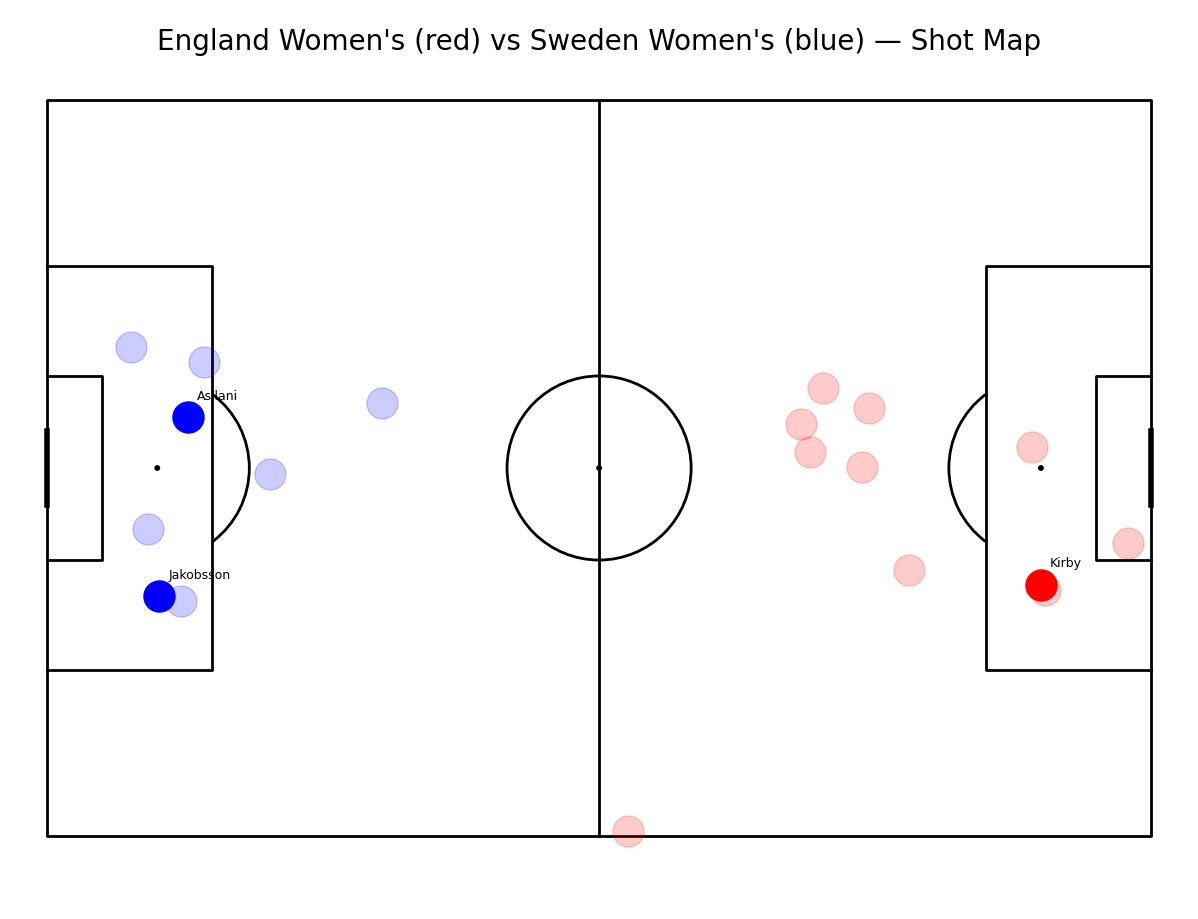

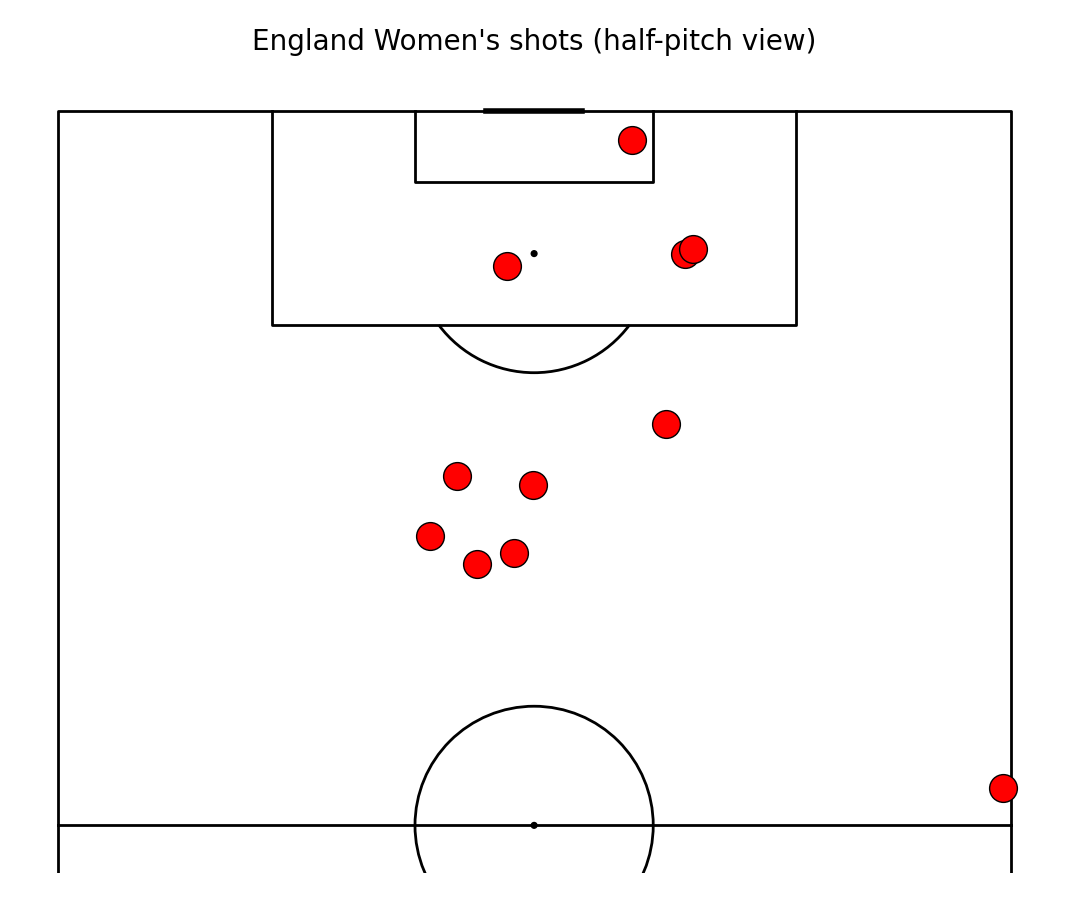

In [3]:
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

# Filter shots per team
df_t1 = df.loc[(df.type_name == 'Shot') & (df.team_name == team1),
               ['x', 'y', 'outcome_name', 'player_name']]
df_t2 = df.loc[(df.type_name == 'Shot') & (df.team_name == team2),
               ['x', 'y', 'outcome_name', 'player_name']]

for _, row in df_t1.iterrows():
    alpha = 1 if row.outcome_name == 'Goal' else 0.2
    pitch.scatter(row.x, row.y, alpha=alpha, s=500, color='red', ax=ax['pitch'])
    if row.outcome_name == 'Goal':
        pitch.annotate(row.player_name.split()[-1], (row.x+1, row.y-2),
                       ax=ax['pitch'], fontsize=9)

for _, row in df_t2.iterrows():
    alpha = 1 if row.outcome_name == 'Goal' else 0.2
    pitch.scatter(120-row.x, 80-row.y, alpha=alpha, s=500, color='blue', ax=ax['pitch'])
    if row.outcome_name == 'Goal':
        pitch.annotate(row.player_name.split()[-1], (120-row.x+1, 80-row.y-2),
                       ax=ax['pitch'], fontsize=9)

fig.suptitle(f'{team1} (red) vs {team2} (blue) — Shot Map', fontsize=20)
plt.show()

# Half-pitch view for one team
pitch2 = VerticalPitch(line_color='black', half=True)
fig2, ax2 = pitch2.grid(grid_height=0.9, title_height=0.06, axis=False,
                        endnote_height=0.04, title_space=0, endnote_space=0)
pitch2.scatter(df_t1.x, df_t1.y, alpha=1, s=400, color='red',
               edgecolors='black', ax=ax2['pitch'])
fig2.suptitle(f'{team1} shots (half-pitch view)', fontsize=20)
plt.show()

### 1.2 Pass Network

A pass network shows the average position of each player (nodes) and the number of passes between them (edges). Node size ∝ total passes made; edge width ∝ passes between that pair.

The **centralisation index** measures how unequally distributed passing is across players. 0 = perfectly equal; 1 = one player touches everything.

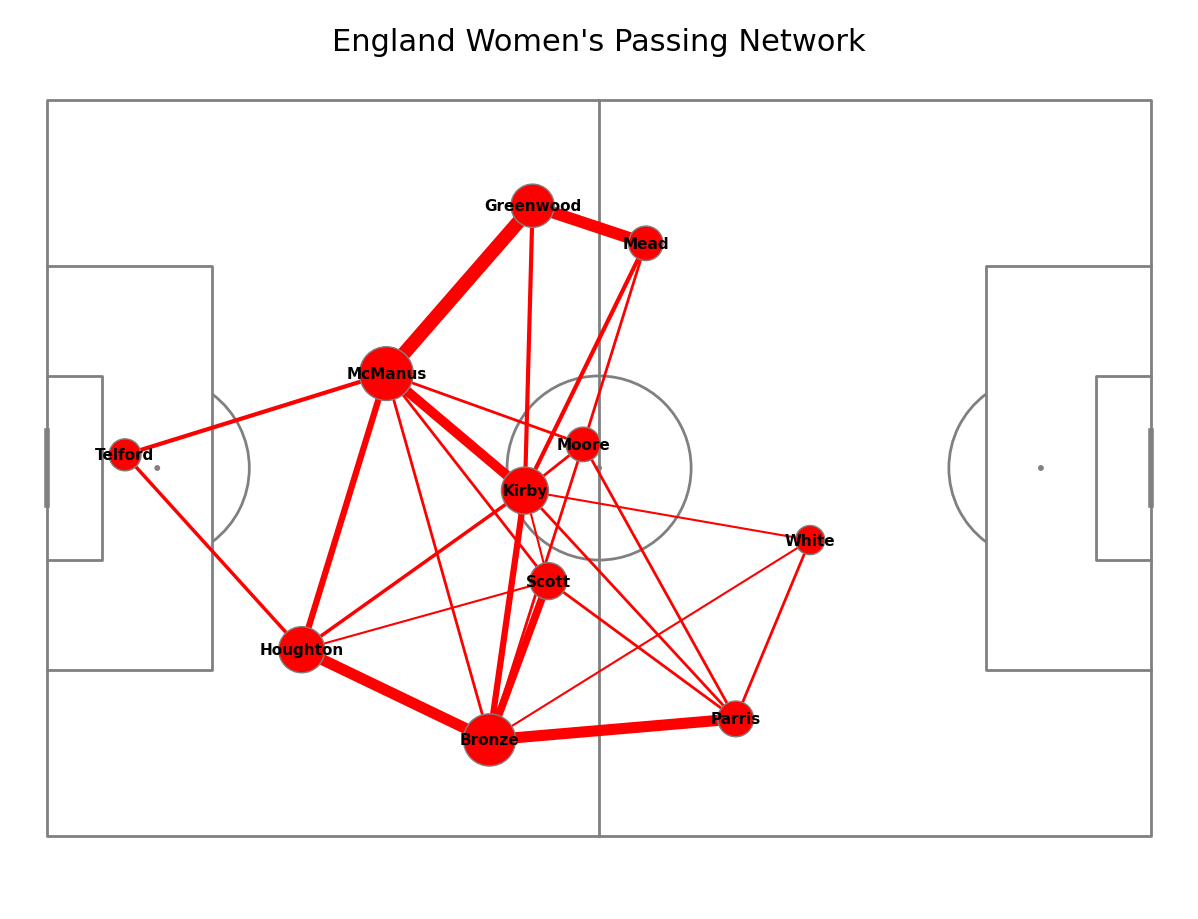

Centralisation index: 0.070  (0=equal, 1=one player dominates)


In [4]:
# Index of first substitution for team1
sub_idx = (df.loc[(df.type_name == 'Substitution') & (df.team_name == team1)]
             .iloc[0]['index'])

# Successful passes before first sub, excluding throw-ins
mask = ((df.type_name == 'Pass') & (df.team_name == team1) &
        (df['index'] < sub_idx) & (df.outcome_name.isnull()) &
        (df.sub_type_name != 'Throw-in'))
df_pass = df.loc[mask, ['x', 'y', 'end_x', 'end_y', 'player_name', 'pass_recipient_name']].copy()
df_pass['player_name']    = df_pass['player_name'].apply(lambda n: str(n).split()[-1])
df_pass['pass_recipient_name'] = df_pass['pass_recipient_name'].apply(lambda n: str(n).split()[-1])

# Node positions = average of passes made + receptions
scatter_df = pd.DataFrame()
for i, name in enumerate(df_pass['player_name'].unique()):
    passx = df_pass.loc[df_pass.player_name == name, 'x'].values
    recx  = df_pass.loc[df_pass.pass_recipient_name == name, 'end_x'].values
    passy = df_pass.loc[df_pass.player_name == name, 'y'].values
    recy  = df_pass.loc[df_pass.pass_recipient_name == name, 'end_y'].values
    scatter_df.at[i, 'player_name'] = name
    scatter_df.at[i, 'x'] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, 'y'] = np.mean(np.concatenate([passy, recy]))
    scatter_df.at[i, 'no'] = df_pass.loc[df_pass.player_name == name].shape[0]
scatter_df['marker_size'] = scatter_df['no'] / scatter_df['no'].max() * 1500

# Edges: pairs with > 2 passes between them
df_pass['pair_key'] = df_pass.apply(
    lambda r: '_'.join(sorted([r.player_name, r.pass_recipient_name])), axis=1)
lines_df = df_pass.groupby('pair_key').x.count().reset_index()
lines_df.columns = ['pair_key', 'pass_count']
lines_df = lines_df[lines_df.pass_count > 2]

# Draw network
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size,
              color='red', edgecolors='grey', ax=ax['pitch'], zorder=3)
for _, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, (row.x, row.y), c='black',
                   va='center', ha='center', weight='bold', size=11,
                   ax=ax['pitch'], zorder=4)

for _, row in lines_df.iterrows():
    p1, p2 = row.pair_key.split('_')
    r1 = scatter_df.loc[scatter_df.player_name == p1].iloc[0]
    r2 = scatter_df.loc[scatter_df.player_name == p2].iloc[0]
    lw = row.pass_count / lines_df.pass_count.max() * 10
    pitch.lines(r1.x, r1.y, r2.x, r2.y, lw=lw, color='red',
                zorder=2, ax=ax['pitch'])

fig.suptitle(f'{team1} Passing Network', fontsize=22)
plt.show()

# Centralisation index
no_passes = df_pass.groupby('player_name').x.count().reset_index()
no_passes.columns = ['player_name', 'pass_count']
max_no = no_passes.pass_count.max()
ci = (max_no - no_passes.pass_count).sum() / (10 * no_passes.pass_count.sum())
print(f'Centralisation index: {ci:.3f}  (0=equal, 1=one player dominates)')

### 1.3 Pass Heatmap

A heatmap bins the pitch into cells and colours each cell by the number of events that started there. Useful for spotting where a team initiates play.

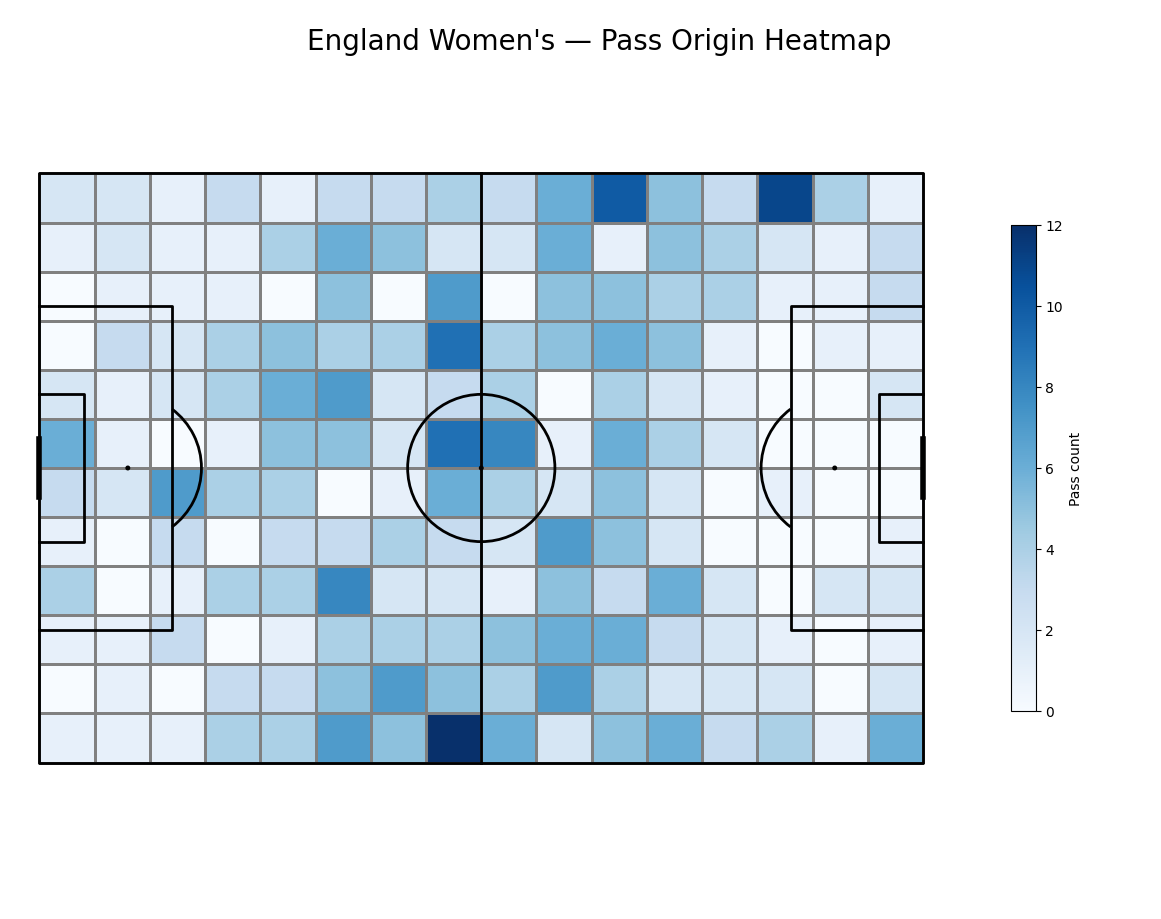

In [5]:
passes_t1 = df.loc[(df.type_name == 'Pass') & (df.team_name == team1)]

pitch = Pitch(line_color='black', line_zorder=2)
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
bs = pitch.bin_statistic(passes_t1.x, passes_t1.y, statistic='count', bins=(16, 12))
pcm = pitch.heatmap(bs, cmap='Blues', edgecolor='grey', ax=ax['pitch'])
fig.colorbar(pcm, ax=ax['pitch'], shrink=0.6, label='Pass count')
fig.suptitle(f'{team1} — Pass Origin Heatmap', fontsize=20)
plt.show()

---
# Part 2 — Expected Goals (xG)

## Background

**Expected Goals (xG)** assigns to each shot a probability that it results in a goal, based on features like:
- Distance from goal
- Angle to goal
- Whether it was a header

**Why not just use raw goals?** Goals are too noisy (lucky deflections, heroic saves). Over a season, xG is a much better predictor of future performance.

### The geometry of shooting

For a shot at position (X, C) where X = distance ahead of goal line and C = lateral distance from centre:

$$\text{Angle} = \arctan\left(\frac{7.32 \cdot X}{X^2 + C^2 - (7.32/2)^2}\right)$$

(7.32m = goal width)

The wider the angle and the shorter the distance, the more of the goal is available to shoot at.

### Logistic regression

We model the binary outcome (goal = 1 or 0) as:

$$P(\text{goal}) = \frac{1}{1 + e^{-(b_0 + b_1 \cdot \text{Angle} + b_2 \cdot \text{Distance} + \ldots)}}$$

Parameters are fit by **maximum likelihood estimation** — we find the $b_i$ that make the observed outcomes most probable.

In [6]:
# Load Wyscout EPL 2017-18 event data (13 files, local)
train = pd.DataFrame()
for i in range(13):
    path = WYSCOUT / f'events_England_{i+1}.json'
    with open(path) as f:
        data = json.load(f)
    train = pd.concat([train, pd.DataFrame(data)], ignore_index=True)

print(f'Total events: {len(train):,}')
print(train['subEventName'].value_counts().head(10))

Total events: 643,150
subEventName
Simple pass               251405
Ground attacking duel      53859
Ground defending duel      53737
Air duel                   37760
Touch                      34409
Ground loose ball duel     31332
Ball out of the field      27331
High pass                  25067
Head pass                  21332
Throw in                   17050
Name: count, dtype: int64


### 2.1 Prepare shot data

Wyscout stores coordinates as percentages (0–100). We convert to metres using a 105×68 pitch.
The goal is placed at x=0 (Wyscout x=100 → our X=0).

In [7]:
shots = train.loc[train['subEventName'] == 'Shot'].copy()

# Convert coordinates: origin = goal line, X = distance ahead of goal
shots['X'] = shots.positions.apply(lambda c: (100 - c[0]['x']) * 105/100)
shots['Y'] = shots.positions.apply(lambda c: c[0]['y'] * 68/100)
shots['C'] = shots.positions.apply(lambda c: abs(c[0]['y'] - 50) * 68/100)  # lateral

shots['Distance'] = np.sqrt(shots['X']**2 + shots['C']**2)
shots['Angle'] = np.where(
    np.arctan(7.32 * shots['X'] / (shots['X']**2 + shots['C']**2 - (7.32/2)**2)) > 0,
    np.arctan(7.32 * shots['X'] / (shots['X']**2 + shots['C']**2 - (7.32/2)**2)),
    np.arctan(7.32 * shots['X'] / (shots['X']**2 + shots['C']**2 - (7.32/2)**2)) + np.pi
)
shots['Goal'] = shots.tags.apply(lambda x: 1 if {'id': 101} in x else 0)

goals = shots.loc[shots['Goal'] == 1]
print(f'Shots: {len(shots):,}  |  Goals: {len(goals):,}  |  Conversion: {len(goals)/len(shots)*100:.1f}%')

Shots: 8,451  |  Goals: 914  |  Conversion: 10.8%


### 2.2 Shot and goal heatmaps

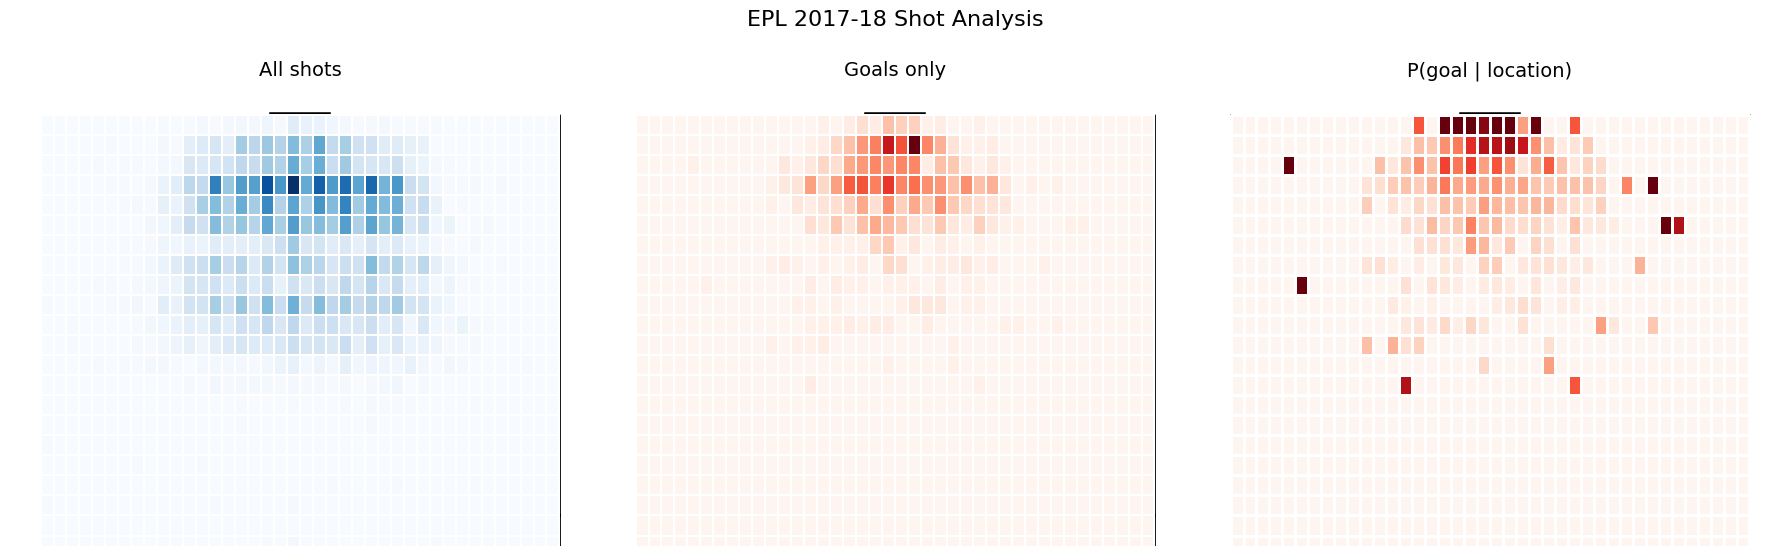

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, title, cmap in zip(
    axes,
    [shots, goals, None],
    ['All shots', 'Goals only', 'P(goal | location)'],
    ['Blues', 'Reds', 'Reds']
):
    pitch = VerticalPitch(line_color='black', half=True,
                          pitch_type='custom', pitch_length=105, pitch_width=68)
    pitch.draw(ax=ax)

    if title != 'P(goal | location)':
        bs = pitch.bin_statistic(105 - data.X, data.Y, bins=40)
        pitch.heatmap(bs, ax=ax, cmap=cmap, edgecolor='white', linewidth=0.01)
    else:
        bs_s = pitch.bin_statistic(105 - shots.X, shots.Y, bins=40)
        bs_g = pitch.bin_statistic(105 - goals.X, goals.Y, bins=40)
        bs_s['statistic'] = np.divide(
            bs_g['statistic'], bs_s['statistic'],
            out=np.zeros_like(bs_g['statistic']), where=bs_s['statistic'] != 0
        )
        pitch.heatmap(bs_s, ax=ax, cmap=cmap, edgecolor='white', vmin=0, vmax=0.6)

    ax.set_title(title, fontsize=14)

plt.suptitle('EPL 2017-18 Shot Analysis', fontsize=16)
plt.tight_layout()
plt.show()

### 2.3 Fit the xG model with logistic regression

In [9]:
# Separate headers from foot shots — they have very different xG curves
headers     = shots.loc[shots.tags.apply(lambda t: {'id': 403} in t)].copy()
non_headers = shots.drop(headers.index).copy()

# Fit two separate models
head_model = smf.glm(formula='Goal ~ Distance + Angle', data=headers,
                     family=sm.families.Binomial()).fit()
foot_model = smf.glm(formula='Goal ~ Distance + Angle', data=non_headers,
                     family=sm.families.Binomial()).fit()

print('=== Foot-shot model ===')
print(foot_model.summary().tables[1])
print('\n=== Header model ===')
print(head_model.summary().tables[1])

=== Foot-shot model ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8183      0.252     -3.253      0.001      -1.311      -0.325
Distance      -0.1152      0.010    -11.000      0.000      -0.136      -0.095
Angle          1.2774      0.218      5.849      0.000       0.849       1.705

=== Header model ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3664      0.934     -0.392      0.695      -2.197       1.464
Distance      -0.2166      0.061     -3.550      0.000      -0.336      -0.097
Angle          0.6923      0.535      1.294      0.196      -0.356       1.741


In [10]:
# Assign xG values back to shots
# model.params is a named Series in statsmodels — use .iloc for positional access
b_h = head_model.params
b_f = foot_model.params

headers['xG']     = 1/(1 + np.exp(b_h.iloc[0] + b_h.iloc[1]*headers['Distance']     + b_h.iloc[2]*headers['Angle']))
non_headers['xG'] = 1/(1 + np.exp(b_f.iloc[0] + b_f.iloc[1]*non_headers['Distance'] + b_f.iloc[2]*non_headers['Angle']))

all_shots = pd.concat([headers, non_headers])

# Top xG single season per player
path = WYSCOUT / 'players.json'
with open(path) as f:
    players_data = json.load(f)
player_df = pd.DataFrame(players_data).rename(columns={'wyId': 'playerId'})

top_xg = (all_shots.groupby('playerId')['xG'].sum()
                   .reset_index()
                   .merge(player_df[['playerId','shortName']], on='playerId')
                   .sort_values('xG', ascending=False)
                   .head(10))
print('Top 10 xG — EPL 2017-18')
print(top_xg[['shortName','xG']].to_string(index=False))

Top 10 xG — EPL 2017-18
      shortName         xG
        H. Kane 139.985820
  Mohamed Salah 118.784181
    Richarlison  79.610660
     C. Eriksen  73.649049
 S. Ag\u00fcero  73.216621
Roberto Firmino  71.200110
 S. Rond\u00f3n  70.487336
   K. De Bruyne  70.110518
    R. Sterling  64.855516
       P. Pogba  63.852708


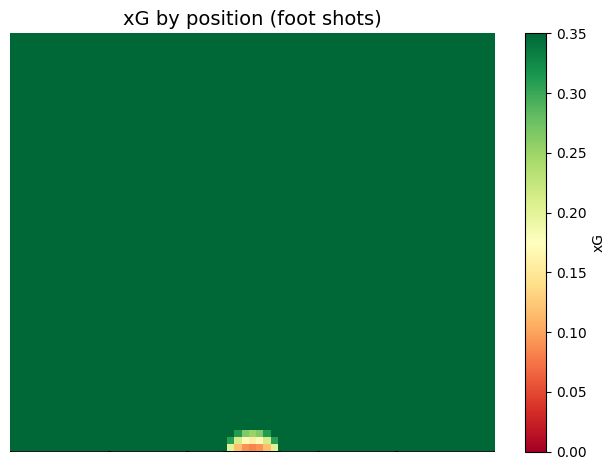

In [11]:
# 2D xG map across the pitch
def calc_xg_position(x, c, model_params):
    b = model_params
    dist = np.sqrt(x**2 + c**2)
    a = np.arctan(7.32 * x / (x**2 + c**2 - (7.32/2)**2))
    if a < 0:
        a += np.pi
    # Use .iloc for positional access on named params Series
    return 1/(1 + np.exp(b.iloc[0] + b.iloc[1]*dist + b.iloc[2]*a))

xg_map = np.zeros((68, 68))
for xi in range(68):
    for yi in range(68):
        xg_map[xi, yi] = calc_xg_position(xi, abs(yi - 34), b_f)

pitch = VerticalPitch(line_color='black', half=True,
                      pitch_type='custom', pitch_length=105, pitch_width=68)
fig, ax = pitch.draw()
pos = ax.imshow(xg_map, extent=[-1, 68, 68, -1], aspect='auto',
                cmap='RdYlGn', vmin=0, vmax=0.35, zorder=1)
fig.colorbar(pos, ax=ax, label='xG')
ax.set_title('xG by position (foot shots)', fontsize=14)
plt.xlim((0, 68)); plt.ylim((0, 60))
plt.show()

### 2.4 Model evaluation — ROC curve and McFadden's R²

The **ROC curve** plots true positive rate vs false positive rate at every probability threshold. A perfect model hugs the top-left corner; random guessing is the diagonal.

**McFadden's R²** ≈ 0.2 is considered a good fit for logistic regression.

McFadden's R² (foot model): 0.1603


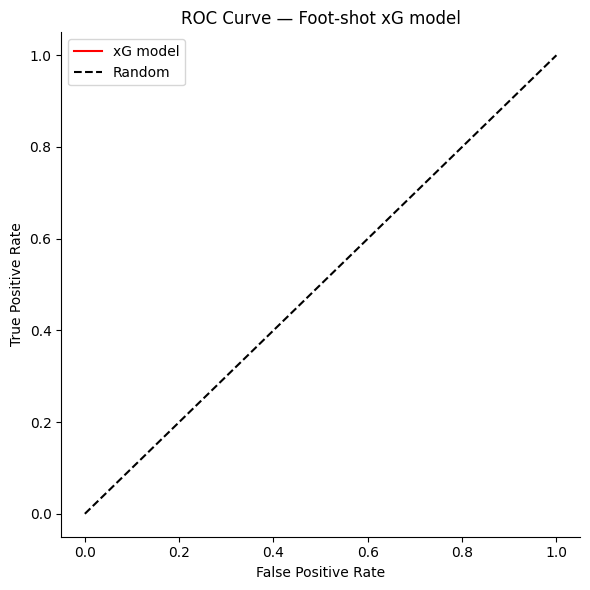

In [12]:
# McFadden's R²
null_model = smf.glm(formula='Goal ~ 1', data=non_headers,
                     family=sm.families.Binomial()).fit()
mcfadden = 1 - foot_model.llf / null_model.llf
print(f"McFadden's R² (foot model): {mcfadden:.4f}")

# ROC curve
numobs = 100
TP = FP = TN = FN = np.zeros(numobs)
thresholds = np.linspace(0, 1, numobs)

for i, thresh in enumerate(thresholds):
    for _, shot in non_headers.iterrows():
        if shot['Goal'] == 1:
            if shot['xG'] > thresh: TP[i] += 1
            else: FN[i] += 1
        else:
            if shot['xG'] > thresh: FP[i] += 1
            else: TN[i] += 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(FP/(FP+TN), TP/(TP+FN), color='red', label='xG model')
ax.plot([0,1], [0,1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Foot-shot xG model')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
# Part 3 — Player Scouting & Radar Plots

## Background

Raw stats (goals, passes) are misleading without context:
1. **Minutes played** — express everything per 90 minutes
2. **Team possession** — a player on a dominant team will naturally touch the ball more. Divide raw counts by their team's possession share while on the pitch.
3. **Position context** — compare forwards to forwards, not to defenders.

**Pizza/radar plots** show percentile ranks across multiple metrics simultaneously. Each slice = one metric; slice size = percentile rank among comparable players.

In [13]:
# Ensure we have the full training set with 2-position events only
train_2pos = train.loc[train.apply(lambda x: len(x.positions) == 2, axis=1)]

# Load minutes played
with open(MINUTES / 'minutes_played_per_game_England.json') as f:
    mpg = json.load(f)
minutes_df = pd.DataFrame(mpg)
minutes = minutes_df.groupby('playerId').minutesPlayed.sum().reset_index()

print(f'Players tracked: {len(minutes)}')

Players tracked: 515


In [14]:
# --- Compute metrics ---

# 1. Non-penalty xG (reuse model from Part 2)
s2 = train.loc[train.eventName == 'Shot'].copy()
s2['X'] = s2.positions.apply(lambda c: (100 - c[0]['x']) * 105/100)
s2['Y'] = s2.positions.apply(lambda c: c[0]['y'] * 68/100)
s2['C'] = s2.positions.apply(lambda c: abs(c[0]['y'] - 50) * 68/100)
s2['Distance'] = np.sqrt(s2.X**2 + s2.C**2)
s2['Angle'] = np.where(
    np.arctan(7.32*s2.X/(s2.X**2 + s2.C**2 - (7.32/2)**2)) > 0,
    np.arctan(7.32*s2.X/(s2.X**2 + s2.C**2 - (7.32/2)**2)),
    np.arctan(7.32*s2.X/(s2.X**2 + s2.C**2 - (7.32/2)**2)) + np.pi
)
s2['Goal'] = s2.tags.apply(lambda t: 1 if {'id':101} in t else 0).astype(object)

h2 = s2.loc[s2.tags.apply(lambda t: {'id':403} in t)].copy()
nh2 = s2.drop(h2.index).copy()
# exclude penalties for npxG
nh2 = nh2.loc[s2.subEventName != 'Penalty']

hm2 = smf.glm('Goal ~ Distance + Angle', data=h2, family=sm.families.Binomial()).fit()
fm2 = smf.glm('Goal ~ Distance + Angle', data=nh2, family=sm.families.Binomial()).fit()

bh2, bf2 = hm2.params, fm2.params
h2['xG']  = 1/(1+np.exp(bh2.iloc[0]+bh2.iloc[1]*h2.Distance+bh2.iloc[2]*h2.Angle))
nh2['xG'] = 1/(1+np.exp(bf2.iloc[0]+bf2.iloc[1]*nh2.Distance+bf2.iloc[2]*nh2.Angle))

npxg_sum = pd.concat([h2[['playerId','xG']], nh2[['playerId','xG']]]).rename(columns={'xG':'npxG'})
npxg_sum = npxg_sum.groupby('playerId').npxG.sum().reset_index()

# 2. Goals, assists, key passes
shots_ev = train.loc[train.subEventName == 'Shot']
passes_ev = train.loc[train.eventName == 'Pass']
goals_ev  = shots_ev.loc[shots_ev.tags.apply(lambda t: {'id':101} in t)]
assists   = passes_ev.loc[passes_ev.tags.apply(lambda t: {'id':301} in t)]
kp        = passes_ev.loc[passes_ev.tags.apply(lambda t: {'id':302} in t)]

g_player  = goals_ev.groupby('playerId').eventId.count().reset_index().rename(columns={'eventId':'goals'})
a_player  = assists.groupby('playerId').eventId.count().reset_index().rename(columns={'eventId':'assists'})
kp_player = kp.groupby('playerId').eventId.count().reset_index().rename(columns={'eventId':'key_passes'})

# 3. Passes into final third
passes_2p = train_2pos.loc[train_2pos.eventName == 'Pass'].copy()
passes_2p['end_x'] = passes_2p.positions.apply(lambda c: c[1]['x'] * 105/100)
acc_passes = passes_2p.loc[passes_2p.tags.apply(lambda t: {'id':1801} in t)]
ft_passes  = acc_passes.loc[acc_passes.end_x > 2*105/3]
ftp_pl = ft_passes.groupby('playerId').end_x.count().reset_index().rename(columns={'end_x':'final_third_passes'})

# Assemble summary
players_uniq = pd.DataFrame(train.playerId.unique(), columns=['playerId'])
summary = (players_uniq
           .merge(npxg_sum, how='left', on='playerId')
           .merge(g_player,  how='left', on='playerId')
           .merge(a_player,  how='left', on='playerId')
           .merge(kp_player, how='left', on='playerId')
           .merge(ftp_pl,    how='left', on='playerId'))
summary = minutes.merge(summary, how='left', on='playerId').fillna(0)
summary = summary.loc[summary.minutesPlayed > 400]

# Load forwards only
with open(WYSCOUT / 'players.json') as f:
    pl = json.load(f)
pl_df = pd.DataFrame(pl).rename(columns={'wyId':'playerId'})
forwards = pl_df.loc[pl_df.apply(lambda r: r.role['name'] == 'Forward', axis=1)]
summary = summary.merge(forwards[['playerId','shortName']], how='inner', on='playerId')

# Per-90 normalisation
stat_cols = ['npxG','goals','assists','key_passes','final_third_passes']
per90 = pd.DataFrame({'shortName': summary.shortName})
for col in stat_cols:
    per90[col+'_p90'] = summary[col] * 90 / summary.minutesPlayed

print(f'Forwards with >400 min: {len(per90)}')
print(per90.sort_values('npxG_p90', ascending=False).head(5)[['shortName','npxG_p90']].to_string())

Forwards with >400 min: 76
         shortName  npxG_p90
23         H. Kane  0.618955
64       O. Niasse  0.579393
18  S. Ag\u00fcero  0.564526
72   Gabriel Jesus  0.533732
61   Mohamed Salah  0.517337


### 3.1 Pizza / Radar Plot for Mohamed Salah

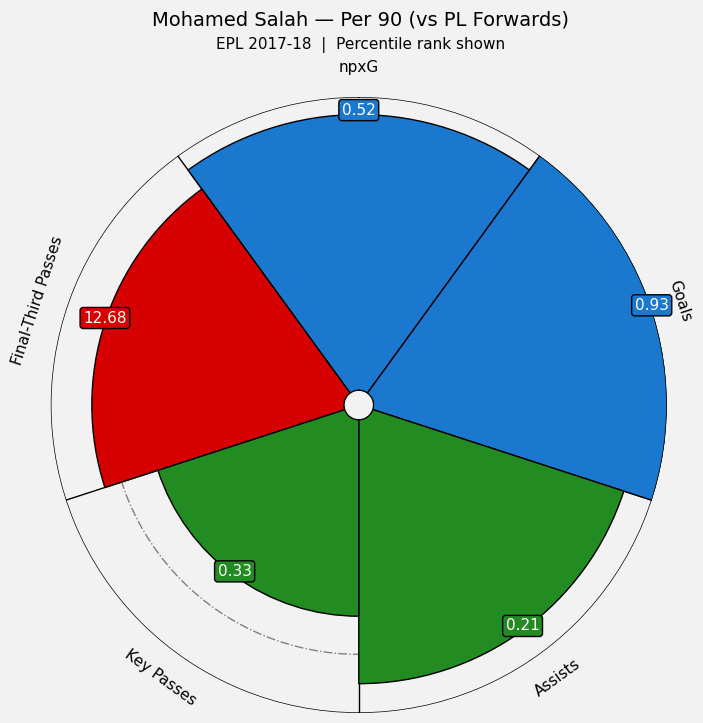

In [15]:
p90_cols = [c+'_p90' for c in stat_cols]
player_row = per90.loc[per90.shortName == 'Mohamed Salah']

if player_row.empty:
    print('Salah not found — using top player instead')
    player_row = per90.sort_values('npxG_p90', ascending=False).head(1)

values     = [round(player_row[c].iloc[0], 2) for c in p90_cols]
percentiles = [int(stats.percentileofscore(per90[c], player_row[c].iloc[0])) for c in p90_cols]
player_name = player_row.shortName.iloc[0]

names = ['npxG', 'Goals', 'Assists', 'Key Passes', 'Final-Third Passes']
colors = ['#1a78cf'] * 2 + ['#228B22'] * 2 + ['#d60000']

baker = PyPizza(
    params=names,
    straight_line_color='#000000', straight_line_lw=1,
    last_circle_lw=1, other_circle_lw=1, other_circle_ls='-.'
)
fig, ax = baker.make_pizza(
    percentiles, figsize=(8, 8), param_location=110,
    slice_colors=colors, value_colors=['white']*5, value_bck_colors=colors,
    kwargs_slices=dict(facecolor='cornflowerblue', edgecolor='#000000', zorder=2, linewidth=1),
    kwargs_params=dict(color='#000000', fontsize=11, va='center'),
    kwargs_values=dict(color='#000000', fontsize=11,
                       bbox=dict(edgecolor='#000000', facecolor='cornflowerblue',
                                 boxstyle='round,pad=0.2', lw=1))
)
for i, text in enumerate(baker.get_value_texts()):
    text.set_text(str(values[i]))
fig.text(0.515, 0.97, f'{player_name} — Per 90 (vs PL Forwards)', size=14, ha='center')
fig.text(0.515, 0.94, 'EPL 2017-18  |  Percentile rank shown', size=11, ha='center')
plt.show()

---
# Part 4 — Expected Threat (xT)

## Background

**Expected Threat** (Karun Singh, 2018) values every ball possession action — not just shots.

The core idea: divide the pitch into a grid (16×12 = 192 zones). For each zone, calculate:
- $P(\text{shoot})$ — probability a player shoots from here
- $P(\text{goal} | \text{shoot})$ — probability a shot here results in a goal (simplified xG)
- $P(\text{move})$ — probability a player moves the ball elsewhere
- $T(z \to z')$ — transition matrix: given a move from zone $z$, what's the prob of ending in $z'$?

Then iterate:
$$xT(z) = P(\text{shoot}, z) \cdot P(\text{goal}|\text{shoot}, z) + P(\text{move}, z) \cdot \sum_{z'} T(z \to z') \cdot xT(z')$$

After ~6 iterations this converges. The xT of an action = $xT(\text{end zone}) - xT(\text{start zone})$.

In [16]:
from scipy.stats import binned_statistic_2d

# Reload full event data
df_xt = pd.DataFrame()
for i in range(13):
    path = WYSCOUT / f'events_England_{i+1}.json'
    with open(path) as f:
        data = json.load(f)
    df_xt = pd.concat([df_xt, pd.DataFrame(data)], ignore_index=True)

# Mark whether next event was ball out of field
next_event = df_xt.shift(-1, fill_value=0)
df_xt['nextEvent'] = next_event['subEventName']
df_xt['kickedOut'] = (df_xt['nextEvent'] == 'Ball out of the field').astype(int)

# Moving actions
move_df = df_xt.loc[df_xt.subEventName.isin(
    ['Simple pass','High pass','Head pass','Smart pass','Cross'])].copy()
move_df = move_df.loc[move_df.kickedOut == 0]

move_df['x']     = move_df.positions.apply(lambda c: c[0]['x'] * 105/100)
move_df['y']     = move_df.positions.apply(lambda c: (100 - c[0]['y']) * 68/100)
move_df['end_x'] = move_df.positions.apply(lambda c: c[1]['x'] * 105/100)
move_df['end_y'] = move_df.positions.apply(lambda c: (100 - c[1]['y']) * 68/100)
# Drop out-of-bounds endpoints
move_df = move_df.loc[~(((move_df.end_x == 0) & (move_df.end_y == 68)) |
                        ((move_df.end_x == 105) & (move_df.end_y == 0)))]

# Shots and goals
shot_df = df_xt.loc[df_xt.subEventName == 'Shot'].copy()
shot_df['x'] = shot_df.positions.apply(lambda c: c[0]['x'] * 105/100)
shot_df['y'] = shot_df.positions.apply(lambda c: (100 - c[0]['y']) * 68/100)
goal_df = shot_df.loc[shot_df.tags.apply(lambda t: {'id':101} in t)]

pitch_xt = Pitch(line_color='black', pitch_type='custom',
                 pitch_length=105, pitch_width=68, line_zorder=2)

move  = pitch_xt.bin_statistic(move_df.x, move_df.y, statistic='count', bins=(16,12))
shot  = pitch_xt.bin_statistic(shot_df.x, shot_df.y, statistic='count', bins=(16,12))
goal  = pitch_xt.bin_statistic(goal_df.x, goal_df.y, statistic='count', bins=(16,12))

move_count = move['statistic']
shot_count = shot['statistic']
goal_count = goal['statistic']

print(f'Move events: {move_count.sum():,.0f}  |  Shots: {shot_count.sum():,.0f}  |  Goals: {goal_count.sum():,.0f}')

Move events: 307,751  |  Shots: 8,451  |  Goals: 914


In [17]:
# Probabilities
total = move_count + shot_count
move_prob = np.divide(move_count, total, out=np.zeros_like(total, dtype=float), where=total != 0)
shot_prob = np.divide(shot_count, total, out=np.zeros_like(total, dtype=float), where=total != 0)
goal_prob = np.divide(goal_count, shot_count, out=np.zeros_like(shot_count, dtype=float), where=shot_count != 0)

# Transition matrices for each zone
def get_sector(x, y):
    res = binned_statistic_2d(
        np.ravel(x), np.ravel(y), values='None', statistic='count',
        bins=(16, 12), range=[[0, 105], [0, 68]], expand_binnumbers=True
    )
    return tuple(r[0] for r in res[3])

move_df['start_sector'] = move_df.apply(lambda r: get_sector(r.x, r.y), axis=1)
move_df['end_sector']   = move_df.apply(lambda r: get_sector(r.end_x, r.end_y), axis=1)

df_starts = move_df.groupby('start_sector').eventId.count().reset_index()
df_starts.columns = ['start_sector', 'count_starts']

transition_matrices = []
for _, row in df_starts.iterrows():
    sector_events = move_df.loc[move_df.start_sector == row.start_sector]
    ends = sector_events.groupby('end_sector').eventId.count().reset_index()
    ends.columns = ['end_sector', 'count_ends']
    T = np.zeros((12, 16))
    for _, r2 in ends.iterrows():
        es = r2.end_sector
        T[es[1]-1][es[0]-1] = r2.count_ends
    T /= row.count_starts
    transition_matrices.append(T)

print(f'Transition matrices computed: {len(transition_matrices)}')

Transition matrices computed: 192


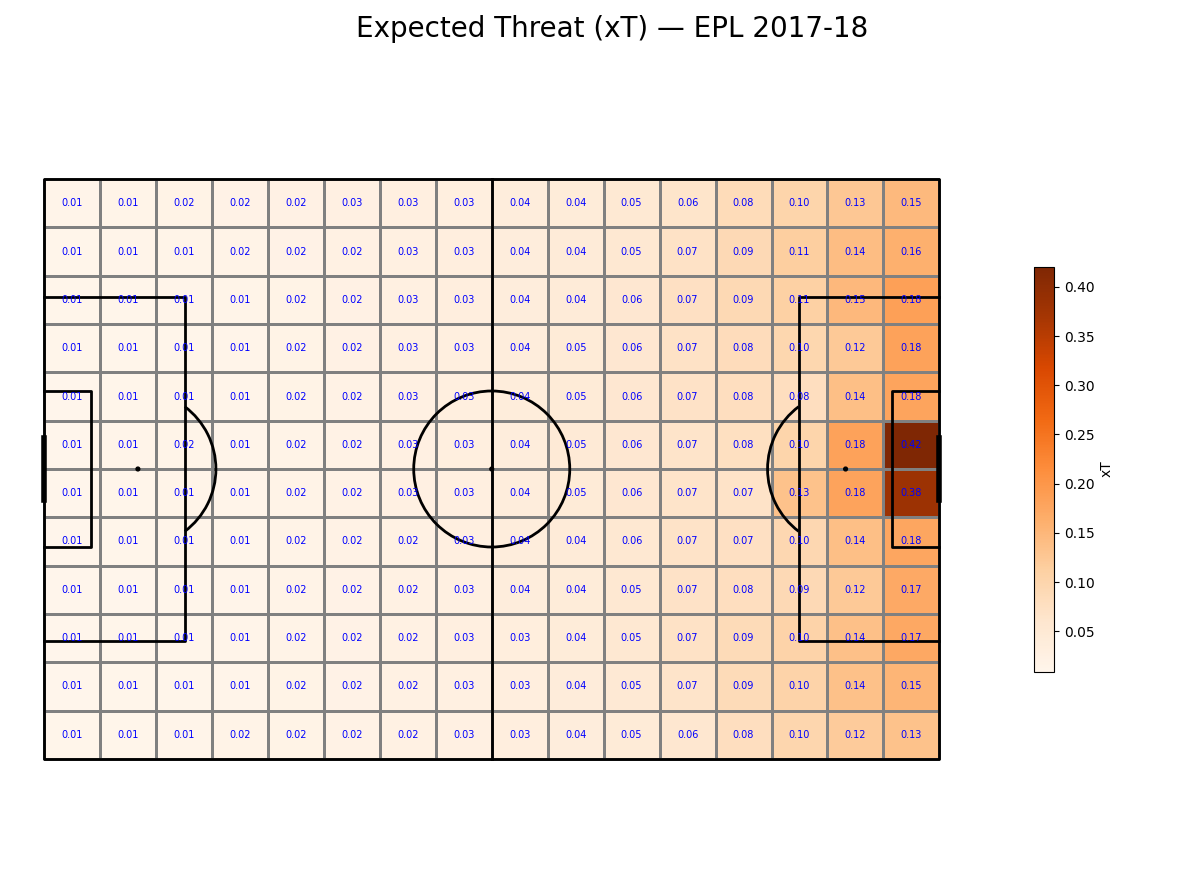

In [18]:
# Iterate xT to convergence (6 steps is enough)
T_arr = np.array(transition_matrices)
xT = np.zeros((12, 16))

for iteration in range(6):
    shoot_payoff = goal_prob * shot_prob
    move_payoff  = move_prob * (np.sum(
        np.sum(T_arr * xT, axis=2), axis=1).reshape(16, 12).T)
    xT = shoot_payoff + move_payoff

# Visualise final xT map
fig, ax = pitch_xt.grid(grid_height=0.9, title_height=0.06, axis=False,
                        endnote_height=0.01, title_space=0, endnote_space=0)
goal['statistic'] = xT
pcm = pitch_xt.heatmap(goal, cmap='Oranges', edgecolor='grey', ax=ax['pitch'])
labels = pitch_xt.label_heatmap(goal, color='blue', fontsize=7,
                                 ax=ax['pitch'], ha='center', va='center',
                                 str_format='{0:.2f}', zorder=3)
fig.colorbar(pcm, ax=ax['pitch'], shrink=0.5, label='xT')
fig.suptitle('Expected Threat (xT) — EPL 2017-18', fontsize=20)
plt.show()

In [19]:
# Assign xT to successful progressive moves
successful = move_df.loc[move_df.tags.apply(lambda t: {'id':1801} in t)].copy()
successful['xT_added'] = successful.apply(
    lambda r: xT[r.end_sector[1]-1][r.end_sector[0]-1]
            - xT[r.start_sector[1]-1][r.start_sector[0]-1], axis=1
)
value_actions = successful.loc[successful.xT_added > 0]

xT_by_player = value_actions.groupby('playerId').xT_added.sum().reset_index()
xT_summary = (minutes.merge(xT_by_player, how='left', on='playerId')
                      .merge(player_df[['playerId','shortName']], how='left', on='playerId')
                      .fillna(0)
                      .loc[lambda d: d.minutesPlayed > 400])
xT_summary['xT_per90'] = xT_summary.xT_added * 90 / xT_summary.minutesPlayed

print('Top 10 players by xT per 90 — EPL 2017-18')
print(xT_summary.sort_values('xT_per90', ascending=False)
                .head(10)[['shortName','xT_per90']]
                .to_string(index=False))

Top 10 players by xT per 90 — EPL 2017-18
        shortName  xT_per90
    F\u00e0bregas  1.047822
     K. De Bruyne  1.025680
      David Silva  0.959404
     O. Zinchenko  0.900888
     M. \u00d6zil  0.873644
         P. Pogba  0.855753
     J. Henderson  0.849152
Philippe Coutinho  0.812986
        J. Milner  0.807995
      Fernandinho  0.800196


---
# Part 5 — Match Prediction with Poisson Regression

## Background

**Goal scoring follows a Poisson process**: goals arrive randomly and independently, at a rate $\lambda$.

We model each team's goals as:
$$\log(\lambda_{\text{home}}) = \mu + \text{home\_advantage} + \text{attack}_{\text{home}} + \text{defence}_{\text{away}}$$

Fit via **Poisson GLM** on all home/away pairings in the season. Then:
- Predict $\lambda_{\text{home}}$ and $\lambda_{\text{away}}$ for a fixture
- The **score probability matrix** $P(h, a) = \text{Poisson}(h; \lambda_h) \times \text{Poisson}(a; \lambda_a)$
- Sum the lower triangle = home win; diagonal = draw; upper triangle = away win

In [20]:
# Load EPL 2021-22 results from football-data.co.uk
epl = pd.read_csv('https://www.football-data.co.uk/mmz4281/2122/E0.csv')
epl = epl.rename(columns={'FTHG':'HomeGoals','FTAG':'AwayGoals'})
epl = epl[['HomeTeam','AwayTeam','HomeGoals','AwayGoals']].dropna()
# Remove last ~10 games (use for out-of-sample testing)
epl_train = epl[:-10].copy()
print(f'Matches: {len(epl_train)}')
print(epl_train.head())

Matches: 370
     HomeTeam        AwayTeam  HomeGoals  AwayGoals
0   Brentford         Arsenal          2          0
1  Man United           Leeds          5          1
2     Burnley        Brighton          1          2
3     Chelsea  Crystal Palace          3          0
4     Everton     Southampton          3          1


In [21]:
# Reshape: each match becomes 2 rows (one per team)
goal_data = pd.concat([
    epl_train[['HomeTeam','AwayTeam','HomeGoals']].assign(home=1)
             .rename(columns={'HomeTeam':'team','AwayTeam':'opponent','HomeGoals':'goals'}),
    epl_train[['AwayTeam','HomeTeam','AwayGoals']].assign(home=0)
             .rename(columns={'AwayTeam':'team','HomeTeam':'opponent','AwayGoals':'goals'})
])

poisson_model = smf.glm(
    formula='goals ~ home + team + opponent',
    data=goal_data, family=sm.families.Poisson()
).fit()

print(poisson_model.summary().tables[0])

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                  740
Model:                            GLM   Df Residuals:                      700
Model Family:                 Poisson   Df Model:                           39
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1043.1
Date:                Mon, 03 Aug 2026   Deviance:                       776.72
Time:                        10:31:01   Pearson chi2:                     681.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2498
Covariance Type:            nonrobust                                         


Expected goals — Man City: 2.48   Arsenal: 0.68


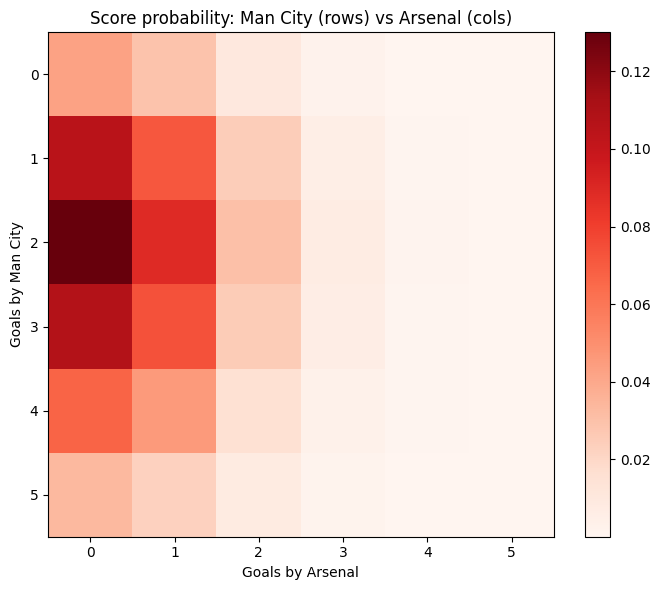

Man City win: 76.7%  |  Draw: 15.1%  |  Arsenal win: 8.2%


In [22]:
def simulate_match(model, home_team, away_team, max_goals=10):
    """Return (max_goals+1)×(max_goals+1) probability matrix for all score lines."""
    lam_h = model.predict(pd.DataFrame({'team': home_team, 'opponent': away_team, 'home': 1}, index=[1])).values[0]
    lam_a = model.predict(pd.DataFrame({'team': away_team, 'opponent': home_team, 'home': 0}, index=[1])).values[0]
    ph = [poisson.pmf(i, lam_h) for i in range(max_goals+1)]
    pa = [poisson.pmf(i, lam_a) for i in range(max_goals+1)]
    return np.outer(np.array(ph), np.array(pa)), lam_h, lam_a

home_team = 'Man City'
away_team = 'Arsenal'

matrix, lam_h, lam_a = simulate_match(poisson_model, home_team, away_team)
print(f'Expected goals — {home_team}: {lam_h:.2f}   {away_team}: {lam_a:.2f}')

max_g = 5
fig, ax = plt.subplots(figsize=(7, 6))
pos = ax.imshow(matrix[:max_g+1, :max_g+1], cmap='Reds', aspect='auto')
fig.colorbar(pos, ax=ax)
ax.set_title(f'Score probability: {home_team} (rows) vs {away_team} (cols)', fontsize=12)
ax.set_xlabel(f'Goals by {away_team}')
ax.set_ylabel(f'Goals by {home_team}')
plt.tight_layout()
plt.show()

# Win/draw/loss probabilities
hw = np.sum(np.tril(matrix, -1))
draw = np.sum(np.diag(matrix))
aw = np.sum(np.triu(matrix, 1))
print(f'{home_team} win: {hw*100:.1f}%  |  Draw: {draw*100:.1f}%  |  {away_team} win: {aw*100:.1f}%')

### 5.1 Simulate a full league season

By running the Poisson model for every fixture, we can simulate a whole season thousands of times to estimate the probability distribution of final standings.

In [23]:
teams = epl_train.HomeTeam.unique()
N_SIM = 500
points_dist = {t: [] for t in teams}

for _ in range(N_SIM):
    pts = {t: 0 for t in teams}
    for _, row in epl_train.iterrows():
        h, a = row.HomeTeam, row.AwayTeam
        try:
            mat, _, _ = simulate_match(poisson_model, h, a)
            hg = np.random.choice(range(11), p=mat.sum(axis=1)/mat.sum())
            ag = np.random.choice(range(11), p=mat.sum(axis=0)/mat.sum())
            if hg > ag:  pts[h] += 3
            elif hg == ag: pts[h] += 1; pts[a] += 1
            else: pts[a] += 3
        except Exception:
            pass
    for t in teams:
        points_dist[t].append(pts[t])

mean_pts = {t: np.mean(v) for t, v in points_dist.items()}
simulated_table = pd.DataFrame.from_dict(mean_pts, orient='index', columns=['sim_pts'])
simulated_table = simulated_table.sort_values('sim_pts', ascending=False)

print('Simulated final standings (mean points over', N_SIM, 'seasons)')
print(simulated_table.head(10).to_string())

Simulated final standings (mean points over 500 seasons)
                sim_pts
Man City         90.046
Liverpool        87.268
Chelsea          76.346
Tottenham        65.956
West Ham         58.662
Arsenal          57.514
Crystal Palace   53.924
Man United       53.136
Leicester        52.668
Aston Villa      50.654


---
# Part 6 — Pitch Control: Voronoi Diagrams

## Background

**Pitch control** answers: *who owns each square metre of the pitch at a given moment?*

The simplest model is a **Voronoi diagram** — each zone belongs to the nearest player. More advanced models (Laurie Shaw's model used at Man City) also account for player speed and direction, but Voronoi gives a useful first approximation.

We use **StatsBomb 360 data** which provides the freeze-frame positions of all visible players at the moment of each event.

In [24]:
# Sweden vs Switzerland, Women's Euro 2022 (StatsBomb 360)
parser = Sbopen()
df_event = parser.event(3835331)[0]

# Find Hanna Bennison's goal
event = df_event.loc[(df_event.outcome_name == 'Goal') &
                     (df_event.player_name == 'Hanna Ulrika Bennison')]
event_id = event['id'].iloc[0]
print(f'Event ID: {event_id}  |  Minute: {event.minute.iloc[0]}')

# 360 frame data
df_frame, df_visible = parser.frame(3835331)
visible_area = np.array(
    df_visible.loc[df_visible['id'] == event_id]['visible_area'].iloc[0]
).reshape(-1, 2)

player_pos  = df_frame.loc[df_frame['id'] == event_id]
sweden = player_pos.loc[player_pos.teammate == True]
swiss  = player_pos.loc[player_pos.teammate == False]

Event ID: 8696a64b-a4dc-43f5-98a5-e7f4503ac838  |  Minute: 78


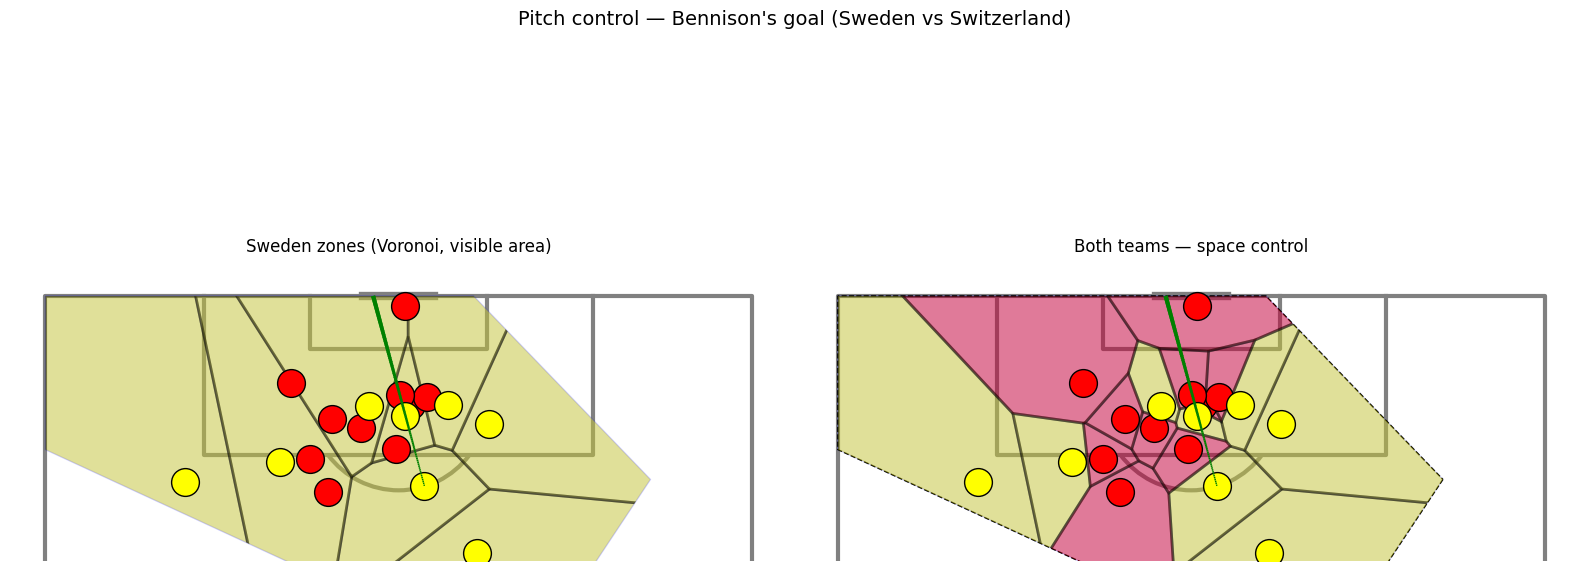

In [25]:
pitch_v = VerticalPitch(line_color='grey', half=True, pad_bottom=-30, linewidth=3)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax_idx, ax in enumerate(axes):
    pitch_v.draw(ax=ax)
    pitch_v.polygon([visible_area], color=(0, 0, 1, 0.2), ax=ax, zorder=1)

    if ax_idx == 0:
        # Single team Voronoi
        team1_v, _ = pitch_v.voronoi(sweden.x, sweden.y, sweden.teammate)
        polys = pitch_v.polygon(team1_v, ax=ax, color='yellow', ec='black', lw=2, alpha=0.4, zorder=2)
        for p in polys:
            p.set_clip_path(pitch_v.polygon([visible_area], color='None', ax=ax)[0])
        ax.set_title('Sweden zones (Voronoi, visible area)', fontsize=12)
    else:
        # Both teams
        t1, t2 = pitch_v.voronoi(player_pos.x, player_pos.y, player_pos.teammate)
        clip = pitch_v.polygon([visible_area], color='None', ec='black', ls='--', ax=ax)[0]
        for p in pitch_v.polygon(t1, ax=ax, color='yellow', ec='black', lw=2, alpha=0.4, zorder=2):
            p.set_clip_path(clip)
        for p in pitch_v.polygon(t2, ax=ax, color='red', ec='black', lw=2, alpha=0.4, zorder=2):
            p.set_clip_path(clip)
        ax.set_title('Both teams — space control', fontsize=12)

    pitch_v.scatter(sweden.x, sweden.y, color='yellow', edgecolors='black', s=400, ax=ax, zorder=4)
    pitch_v.scatter(swiss.x,  swiss.y,  color='red',    edgecolors='black', s=400, ax=ax, zorder=3)
    pitch_v.lines(event.x, event.y, event.end_x, event.end_y,
                  comet=True, color='green', ax=ax, zorder=5, lw=3, ls=':')

fig.suptitle("Pitch control — Bennison's goal (Sweden vs Switzerland)", fontsize=14)
plt.tight_layout()
plt.show()

---
# Part 7 — Clustering Players by Role

## Background

Unsupervised learning can group players into tactical roles purely from statistics — no labels needed.

**Workflow:**
1. Collect per-90 statistics for every player
2. Standardise (z-score) so no metric dominates
3. Reduce to 2D with **UMAP** or **PCA + t-SNE** (preserves local structure, separates clusters)
4. Apply **hierarchical clustering** or **Gaussian Mixture Model**
5. Inspect which players fell in which cluster to label the roles

The lesson uses an external dataset (`data.csv` from Ronan Manning / FBref). Below we replicate the concept with the Wyscout data already in the repo, using PCA + t-SNE.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.pipeline import Pipeline

# Build a multi-stat summary per player from Wyscout data
def safe_count(df, cond, label):
    return (df.loc[cond].groupby('playerId')
              .eventId.count().reset_index()
              .rename(columns={'eventId': label}))

ev = train.copy()
shots_cl = safe_count(ev, ev.subEventName == 'Shot', 'shots')
goals_cl  = safe_count(ev, ev.tags.apply(lambda t: {'id':101} in t) & (ev.subEventName == 'Shot'), 'goals')
passes_cl = safe_count(ev, ev.eventName == 'Pass', 'passes')
acc_cl    = safe_count(ev, (ev.eventName == 'Pass') & ev.tags.apply(lambda t: {'id':1801} in t), 'acc_passes')
duels_cl  = safe_count(ev, ev.eventName == 'Duel', 'duels')

cluster_df = (minutes
              .merge(shots_cl, how='left', on='playerId')
              .merge(goals_cl, how='left', on='playerId')
              .merge(passes_cl, how='left', on='playerId')
              .merge(acc_cl, how='left', on='playerId')
              .merge(duels_cl, how='left', on='playerId')
              .fillna(0)
              .loc[lambda d: d.minutesPlayed > 400]
              .merge(player_df[['playerId','shortName']], how='left', on='playerId')
              .dropna(subset=['shortName']))

# Normalise to per-90
stat_cols_cl = ['shots','goals','passes','acc_passes','duels']
for col in stat_cols_cl:
    cluster_df[col+'_p90'] = cluster_df[col] * 90 / cluster_df.minutesPlayed

X_cl = cluster_df[[c+'_p90' for c in stat_cols_cl]].values
X_scaled = StandardScaler().fit_transform(X_cl)

print(f'Players for clustering: {len(cluster_df)}')

Players for clustering: 397


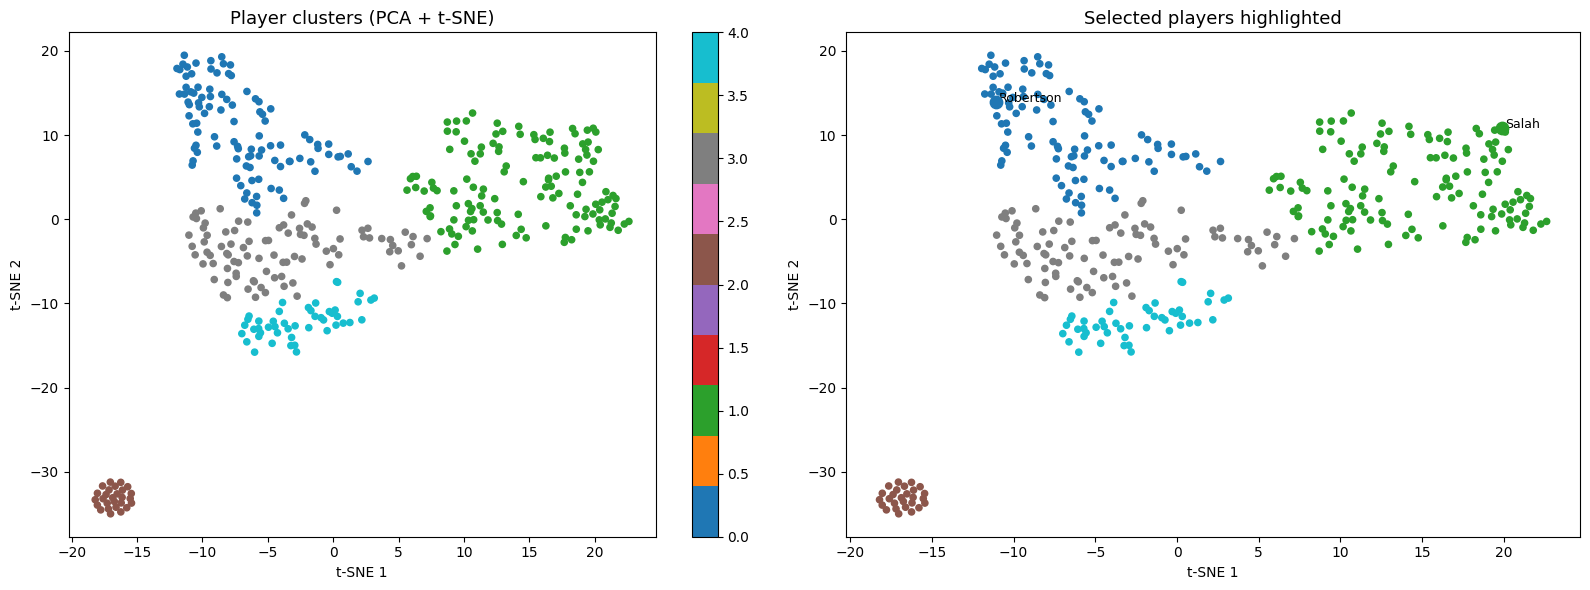


Cluster means (per 90):
         shots_p90  goals_p90  passes_p90  acc_passes_p90  duels_p90
cluster                                                             
0             0.77       0.05       58.39           51.04      17.83
1             1.94       0.25       28.70           22.39      25.12
2             0.00       0.00       17.31           14.09       0.82
3             0.55       0.03       36.57           29.77      17.69
4             0.27       0.01       29.94           22.88      16.00


In [27]:
# Dimensionality reduction: PCA → t-SNE
pipeline = Pipeline([('pca', PCA(n_components=5)), ('tsne', TSNE(random_state=42, perplexity=30))])
comps = pipeline.fit_transform(X_scaled)

# Cluster into 5 groups
n_clusters = 5
labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(comps)
cluster_df['cluster'] = labels

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax in axes:
    scatter = ax.scatter(comps[:, 0], comps[:, 1], c=labels, s=20, cmap='tab10')

axes[0].set_title('Player clusters (PCA + t-SNE)', fontsize=13)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=axes[0])

# Annotate a few well-known players
known = ['Mohamed Salah','Harry Kane','N. Fernandinho','D. De Gea','A. Robertson']
for _, row in cluster_df.loc[cluster_df.shortName.isin(known)].iterrows():
    idx = cluster_df.index.get_loc(row.name)
    axes[1].scatter(comps[idx, 0], comps[idx, 1], s=80, zorder=5,
                    c=[labels[idx]], cmap='tab10', vmin=0, vmax=n_clusters)
    axes[1].annotate(row.shortName.split()[-1], (comps[idx, 0]+0.2, comps[idx, 1]),
                     fontsize=9)

axes[1].scatter(comps[:, 0], comps[:, 1], c=labels, s=10, cmap='tab10', alpha=0.4)
axes[1].set_title('Selected players highlighted', fontsize=13)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

# Cluster centroids (mean per-90 stats)
print('\nCluster means (per 90):')
print(cluster_df.groupby('cluster')[[c+'_p90' for c in stat_cols_cl]].mean().round(2).to_string())

---
# Part 8 — Key Takeaways

| Concept | Formula / Method | Use case |
|---------|-----------------|----------|
| **xG** | Logistic regression on distance + angle | Evaluate shot quality; compare strikers fairly |
| **xT** | Iterative Markov chain on 16×12 grid | Value passes and dribbles, not just shots |
| **Pass network** | Graph where nodes = avg position, edges = pass count | See tactical structure; centralisation index |
| **Radar / pizza** | Percentile ranks, possession-adjusted per 90 | Multi-dimensional player comparison |
| **Poisson model** | GLM with team + opponent + home fixed effects | Pre-match probabilities; simulate seasons |
| **Voronoi** | Nearest-player spatial partitioning | Instantaneous pitch control from snapshot |
| **Clustering** | PCA/UMAP + hierarchical / GMM | Auto-discover player roles from statistics |

### What good football analytics looks like
1. **Per-90 normalisation** — always adjust for minutes played
2. **Possession adjustment** — divide by team possession share
3. **Context** — compare within positions and comparable leagues
4. **Uncertainty** — randomness is huge in football; small samples mislead
5. **Validation** — check model fit (ROC, R², calibration plots)

---
# Part 9 — New Dataset: Replicate Everything with StatsBomb La Liga

## Why La Liga (Messi era)?

StatsBomb's free open data includes **Messi's entire La Liga career at Barcelona (2004-2021)** — hundreds of matches, 360 data for recent seasons, and well-documented. It's a completely different football context from the EPL Wyscout data used above, making it a genuine test of whether the concepts generalise.

### Available free StatsBomb competitions (selection)
| Competition | Seasons |
|---|---|
| La Liga (Messi era) | 2004-2021 |
| UEFA Champions League | Several |
| Women's Super League | 2018-2021 |
| FIFA World Cup | 2022 |
| UEFA Euro | 2020, 2022 (Women's) |
| NWSL | 2018 |

Use the `statsbombpy` library for easy access to all competitions without manual file downloads.

In [28]:
# Install if needed: pip install statsbombpy
# The mplsoccer Sbopen parser is also sufficient for open data

# ---- What competitions/matches are available? ----
parser = Sbopen()

competitions = parser.competition()
print('Available StatsBomb competitions:')
print(competitions[['competition_name','season_name','competition_id','season_id']]
      .sort_values('competition_name')
      .to_string(index=False))

Available StatsBomb competitions:
       competition_name season_name  competition_id  season_id
          1. Bundesliga   2023/2024               9        281
          1. Bundesliga   2015/2016               9         27
 African Cup of Nations        2023            1267        107
       Champions League   2018/2019              16          4
       Champions League   2017/2018              16          1
       Champions League   2016/2017              16          2
       Champions League   2015/2016              16         27
       Champions League   2014/2015              16         26
       Champions League   2013/2014              16         25
       Champions League   2012/2013              16         24
       Champions League   2011/2012              16         23
       Champions League   2010/2011              16         22
       Champions League   2009/2010              16         21
       Champions League   2008/2009              16         41
       Champions Leag

In [29]:
# ---- Load all La Liga 2020-21 matches ----
# La Liga = competition_id 11;  2020/21 season = season_id 90 (check above output)
# Adjust these IDs based on the output of the cell above

la_liga_competitions = competitions.loc[competitions.competition_name == 'La Liga']
print(la_liga_competitions[['competition_id','season_id','season_name']].to_string(index=False))

 competition_id  season_id season_name
             11         90   2020/2021
             11         42   2019/2020
             11          4   2018/2019
             11          1   2017/2018
             11          2   2016/2017
             11         27   2015/2016
             11         26   2014/2015
             11         25   2013/2014
             11         24   2012/2013
             11         23   2011/2012
             11         22   2010/2011
             11         21   2009/2010
             11         41   2008/2009
             11         40   2007/2008
             11         39   2006/2007
             11         38   2005/2006
             11         37   2004/2005
             11        278   1973/1974


In [30]:
# Pick a season (use the IDs from the output above)
# Example: La Liga 2020-21
COMP_ID   = 11   # La Liga
SEASON_ID = 90   # 2020-21 — adjust if needed

matches = parser.match(competition_id=COMP_ID, season_id=SEASON_ID)
print(f'Matches available: {len(matches)}')
print(matches[['match_id','home_team_name','away_team_name','home_score','away_score']].head(10).to_string(index=False))

Matches available: 35
 match_id   home_team_name away_team_name  home_score  away_score
  3773386 Deportivo Alavés      Barcelona           1           1
  3773565          Granada      Barcelona           0           4
  3773457        Barcelona     Celta Vigo           1           2
  3773631       Real Betis      Barcelona           2           3
  3773665          Osasuna      Barcelona           0           2
  3773497      Real Madrid      Barcelona           2           1
  3773660        Barcelona     Levante UD           1           0
  3773593        Barcelona     Villarreal           4           0
  3773466       Celta Vigo      Barcelona           0           3
  3773585        Barcelona    Real Madrid           1           3


In [31]:
# ---- Load all events for the season ----
# This may take a minute — loads one JSON per match

all_events = pd.DataFrame()
for mid in matches.match_id:
    try:
        ev, _, _, _ = parser.event(mid)
        ev['match_id'] = mid
        all_events = pd.concat([all_events, ev], ignore_index=True)
    except Exception as e:
        print(f'  Skipped match {mid}: {e}')

print(f'Total events loaded: {len(all_events):,}')
print(all_events.type_name.value_counts().head(10))

Total events loaded: 139,030
type_name
Pass             40337
Ball Receipt     39197
Carry            32900
Pressure         10832
Ball Recovery     2822
Duel              1763
Block             1276
Dribble           1206
Clearance         1037
Goal Keeper        994
Name: count, dtype: int64


### 9.1 Replicate — Shot Map for a La Liga match

Match: Deportivo Alavés 1-1 Barcelona


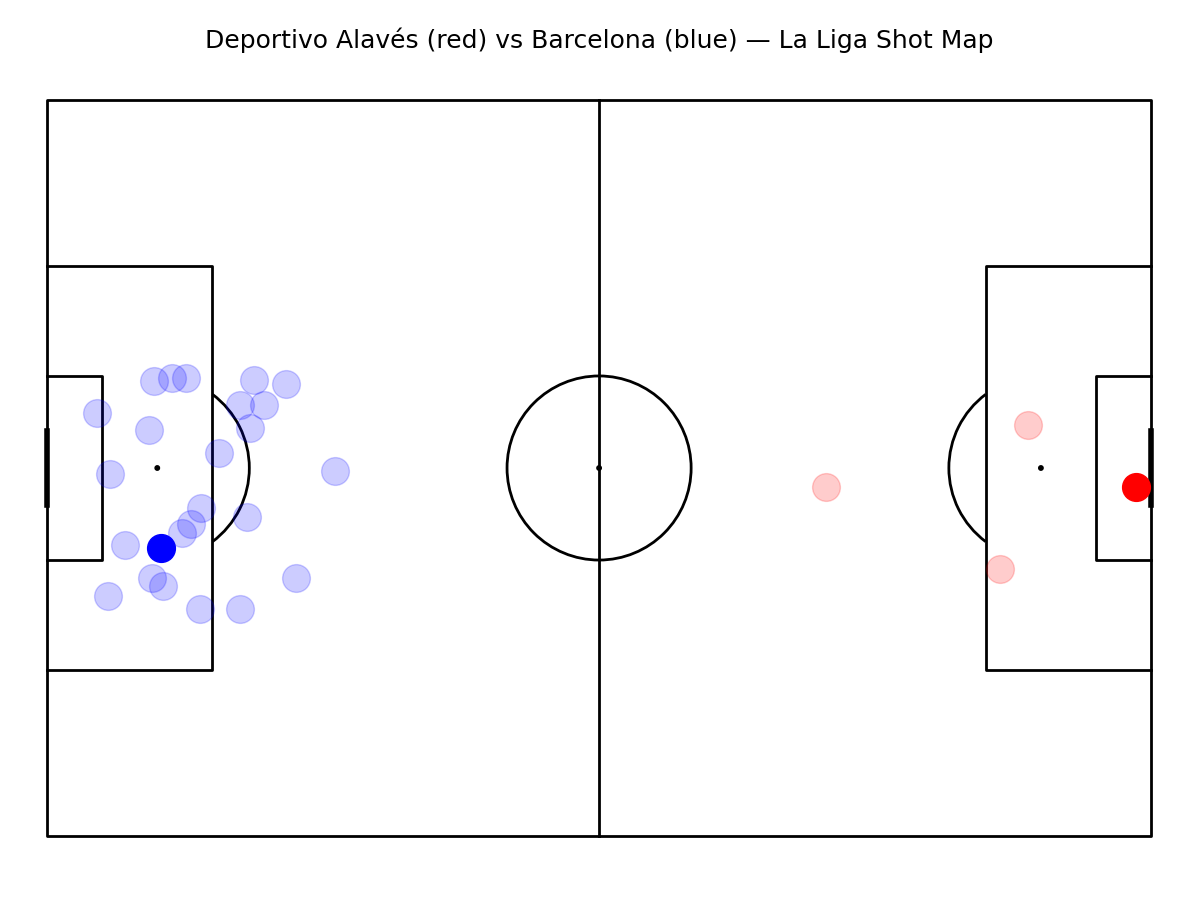

In [32]:
# Pick the first match
sample_match_id = matches.match_id.iloc[0]
match_info = matches.loc[matches.match_id == sample_match_id].iloc[0]
print(f"Match: {match_info['home_team_name']} {match_info['home_score']}-{match_info['away_score']} {match_info['away_team_name']}")

match_events = all_events.loc[all_events.match_id == sample_match_id]
t1_ll, t2_ll = match_events.team_name.unique()[:2]

shots_ll = match_events.loc[match_events.type_name == 'Shot']
df_t1_ll = shots_ll.loc[shots_ll.team_name == t1_ll]
df_t2_ll = shots_ll.loc[shots_ll.team_name == t2_ll]

pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

for _, row in df_t1_ll.iterrows():
    alpha = 1 if row.outcome_name == 'Goal' else 0.2
    pitch.scatter(row.x, row.y, alpha=alpha, s=400, color='red', ax=ax['pitch'])

for _, row in df_t2_ll.iterrows():
    alpha = 1 if row.outcome_name == 'Goal' else 0.2
    pitch.scatter(120-row.x, 80-row.y, alpha=alpha, s=400, color='blue', ax=ax['pitch'])

fig.suptitle(f'{t1_ll} (red) vs {t2_ll} (blue) — La Liga Shot Map', fontsize=18)
plt.show()

### 9.2 Replicate — xG model on La Liga shots

StatsBomb uses yards (120×80 pitch). The geometry is the same but the goal is at x=120 and goal width is 8 yards.

In [33]:
shots_ll_all = all_events.loc[all_events.type_name == 'Shot'].copy()

# StatsBomb coords: x runs 0→120 (attacking left to right), y runs 0→80
# Goal is at x=120, centred at y=40. Goal width = 8 yards (y=36→44)
GOAL_WIDTH_YD = 8

shots_ll_all['X'] = 120 - shots_ll_all['x']           # distance from goal line
shots_ll_all['C'] = abs(shots_ll_all['y'] - 40)       # lateral distance from centre
shots_ll_all['Distance'] = np.sqrt(shots_ll_all.X**2 + shots_ll_all.C**2)
shots_ll_all['Angle'] = np.where(
    np.arctan(GOAL_WIDTH_YD * shots_ll_all.X /
              (shots_ll_all.X**2 + shots_ll_all.C**2 - (GOAL_WIDTH_YD/2)**2)) > 0,
    np.arctan(GOAL_WIDTH_YD * shots_ll_all.X /
              (shots_ll_all.X**2 + shots_ll_all.C**2 - (GOAL_WIDTH_YD/2)**2)),
    np.arctan(GOAL_WIDTH_YD * shots_ll_all.X /
              (shots_ll_all.X**2 + shots_ll_all.C**2 - (GOAL_WIDTH_YD/2)**2)) + np.pi
)
shots_ll_all['Goal'] = (shots_ll_all.outcome_name == 'Goal').astype(int)

# Fit xG model (exclude penalties)
ll_shots = shots_ll_all.loc[shots_ll_all.sub_type_name != 'Penalty'].copy()
ll_model = smf.glm(
    formula='Goal ~ Distance + Angle',
    data=ll_shots, family=sm.families.Binomial()
).fit()

b_ll = ll_model.params
ll_shots['xG'] = 1/(1 + np.exp(b_ll.iloc[0] + b_ll.iloc[1]*ll_shots.Distance + b_ll.iloc[2]*ll_shots.Angle))

print(ll_model.summary().tables[1])

# Top scorers by xG
top_ll = (ll_shots.groupby('player_name').agg(
    xG=('xG','sum'), goals=('Goal','sum'), shots=('Goal','count')
).reset_index().sort_values('xG', ascending=False).head(10))
print('\nTop 10 by xG — La Liga 2020-21')
print(top_ll.to_string(index=False))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7414      0.634     -2.748      0.006      -2.983      -0.499
Distance      -0.0607      0.026     -2.325      0.020      -0.112      -0.010
Angle          1.3891      0.489      2.840      0.005       0.430       2.348

Top 10 by xG — La Liga 2020-21
                                     player_name         xG  goals  shots
                  Lionel Andrés Messi Cuccittini 171.518132     27    190
                               Antoine Griezmann  53.532996     11     62
                                 Ousmane Dembélé  41.948782      5     47
                       Philippe Coutinho Correia  23.947725      2     27
                                Jordi Alba Ramos  21.836442      3     24
                            Pedro González López  18.964376      3     22
Francisco António Machado Mota de Castro Trincão  18.23

### 9.3 Replicate — Pass network for a La Liga match

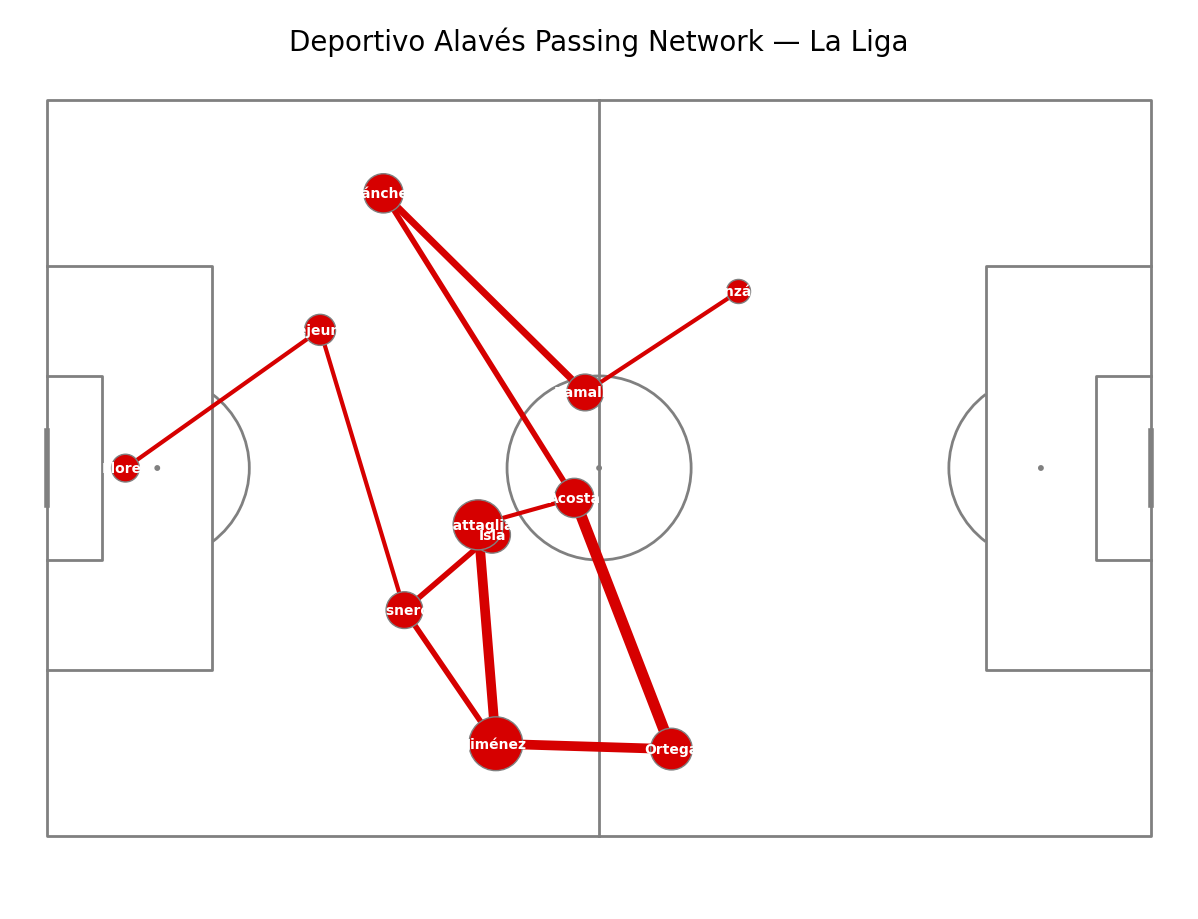

In [34]:
# Use the first match, focus on the home team
ev_match = match_events.copy()

try:
    sub_idx_ll = (ev_match.loc[(ev_match.type_name == 'Substitution') &
                               (ev_match.team_name == t1_ll)]
                           .iloc[0]['index'])
except IndexError:
    sub_idx_ll = ev_match['index'].max()

mask_ll = ((ev_match.type_name == 'Pass') &
           (ev_match.team_name == t1_ll) &
           (ev_match['index'] < sub_idx_ll) &
           (ev_match.outcome_name.isnull()))

df_pass_ll = ev_match.loc[mask_ll, ['x','y','end_x','end_y','player_name','pass_recipient_name']].copy()
df_pass_ll['player_name']         = df_pass_ll['player_name'].apply(lambda n: str(n).split()[-1])
df_pass_ll['pass_recipient_name'] = df_pass_ll['pass_recipient_name'].apply(lambda n: str(n).split()[-1])
df_pass_ll = df_pass_ll.dropna()

# Compute node positions
sc_ll = pd.DataFrame()
for i, name in enumerate(df_pass_ll.player_name.unique()):
    px = df_pass_ll.loc[df_pass_ll.player_name == name, 'x'].values
    rx = df_pass_ll.loc[df_pass_ll.pass_recipient_name == name, 'end_x'].values
    py = df_pass_ll.loc[df_pass_ll.player_name == name, 'y'].values
    ry = df_pass_ll.loc[df_pass_ll.pass_recipient_name == name, 'end_y'].values
    sc_ll.at[i, 'player_name'] = name
    sc_ll.at[i, 'x']  = np.mean(np.concatenate([px, rx]))
    sc_ll.at[i, 'y']  = np.mean(np.concatenate([py, ry]))
    sc_ll.at[i, 'no'] = len(px)
sc_ll['marker_size'] = sc_ll['no'] / sc_ll['no'].max() * 1500

df_pass_ll['pair_key'] = df_pass_ll.apply(
    lambda r: '_'.join(sorted([r.player_name, r.pass_recipient_name])), axis=1)
lines_ll = df_pass_ll.groupby('pair_key').x.count().reset_index()
lines_ll.columns = ['pair_key','pass_count']
lines_ll = lines_ll.loc[lines_ll.pass_count > 2]

pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(sc_ll.x, sc_ll.y, s=sc_ll.marker_size,
              color='#d60000', edgecolors='grey', ax=ax['pitch'], zorder=3)
for _, row in sc_ll.iterrows():
    pitch.annotate(row.player_name, (row.x, row.y), c='white',
                   va='center', ha='center', weight='bold', size=10,
                   ax=ax['pitch'], zorder=4)

for _, row in lines_ll.iterrows():
    p1, p2 = row.pair_key.split('_')
    r1 = sc_ll.loc[sc_ll.player_name == p1]
    r2 = sc_ll.loc[sc_ll.player_name == p2]
    if not r1.empty and not r2.empty:
        lw = row.pass_count / lines_ll.pass_count.max() * 8
        pitch.lines(r1.x.iloc[0], r1.y.iloc[0],
                    r2.x.iloc[0], r2.y.iloc[0],
                    lw=lw, color='#d60000', zorder=2, ax=ax['pitch'])

fig.suptitle(f'{t1_ll} Passing Network — La Liga', fontsize=20)
plt.show()

---
# Part 10 — Where to Find More Data

## Free data sources

| Source | Type | Access | Notes |
|--------|------|--------|-------|
| **StatsBomb Open Data** | Event + 360 | `statsbombpy` / mplsoccer | La Liga (Messi), Women's Super League, World Cup 2022 |
| **football-data.co.uk** | Match results | CSV download | 20+ seasons, all major European leagues |
| **understat.com** | xG per shot | `understat` Python lib | 6 leagues, 2014-present |
| **FBref** | Aggregated stats | `soccerdata` library | Comprehensive player/team stats |
| **Transfermarkt** | Market values | `soccerdata` library | Player values, transfers |
| **Metrica Sports** | Tracking data | GitHub download | 2 anonymised matches |
| **SkillCorner** | Broadcast tracking | Free samples only | Off-ball movement |

## Code to get started with understat (xG for any major league)

```python
# pip install understat
import asyncio
from understat import Understat

async def get_shots(league='La liga', season='2023'):
    async with aiohttp.ClientSession() as session:
        understat = Understat(session)
        shots = await understat.get_league_players(league, season)
        return pd.DataFrame(shots)

# leagues: 'EPL', 'La liga', 'Bundesliga', 'Serie A', 'Ligue 1', 'RFPL'
df_shots = asyncio.run(get_shots('EPL', '2023'))
```

## Code to get started with soccerdata (FBref)

```python
# pip install soccerdata
import soccerdata as sd

fbref = sd.FBref(leagues='ENG-Premier League', seasons='2022-2023')
team_stats  = fbref.read_team_season_stats()
player_stats = fbref.read_player_season_stats()
schedule = fbref.read_schedule()
```

## Suggested projects

| Project | Concepts used | Data needed |
|---------|--------------|-------------|
| Build an xG model for Bundesliga | Logistic regression, geometry | Understat shots |
| Rank Serie A midfielders by xT | xT, per-90, possession adjustment | StatsBomb or Wyscout |
| Predict La Liga 2024-25 winner | Poisson model, simulation | football-data.co.uk |
| Cluster Premier League players by role | UMAP, GMM | FBref via soccerdata |
| Shot quality for Messi vs Ronaldo | xG, radar plots | StatsBomb La Liga |
| Passing network evolution in a season | Pass network, centralisation | StatsBomb per match |

In [35]:
print('Notebook complete!')
print('You have covered:')
topics = [
    '1. Shot maps and event data visualisation',
    '2. Pass networks and centralisation index',
    '3. Expected Goals (xG) with logistic regression',
    '4. ROC curves and model validation',
    '5. Radar / pizza plots for player scouting',
    '6. Expected Threat (xT) via Markov chain',
    '7. Match prediction with Poisson regression',
    '8. Season simulation',
    '9. Pitch control with Voronoi diagrams',
    '10. Player clustering with PCA + t-SNE',
    '11. How to replicate all of the above on La Liga StatsBomb data',
]
for t in topics:
    print(' ', t)

Notebook complete!
You have covered:
  1. Shot maps and event data visualisation
  2. Pass networks and centralisation index
  3. Expected Goals (xG) with logistic regression
  4. ROC curves and model validation
  5. Radar / pizza plots for player scouting
  6. Expected Threat (xT) via Markov chain
  7. Match prediction with Poisson regression
  8. Season simulation
  9. Pitch control with Voronoi diagrams
  10. Player clustering with PCA + t-SNE
  11. How to replicate all of the above on La Liga StatsBomb data
